# Baseline
Ansatz:
- Übersicht der Multi-view Pig Posture Recognition Challenge
- Datenanalyse und -vorverarbeitung
- Baseline Modellierung für zukunfitge Optimierungen

In [27]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import seaborn as sns


## Datenanalyse

In [28]:
# Daten laden
data_dir = "/datasets/multi-view-pig-posture-recognition/"
# Train1 sind Bilder von 5 verschiedenen Kamera
train1_df = pd.read_csv(os.path.join(data_dir, "train1.csv"))
train2_df = pd.read_csv(os.path.join(data_dir, "train2.csv"))
dir_train1 = os.path.join(data_dir, "train1_images")
dir_train2 = os.path.join(data_dir, "train2_images")

test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
dir_test = os.path.join(data_dir, "test_images")

In [29]:
# Datenüberblick der trainings spalten
train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [30]:
# Datenüberblick der Test spalten
test_df.head()

,row_id,image_id,width,height,bbox
0,test_pen1_tur_cam1_20250920_174649_0000,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[432.0,291.0,306.0,394.0]"
1,test_pen1_tur_cam1_20250920_174649_0001,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[237.0,254.0,246.0,402.0]"
2,test_pen1_tur_cam1_20250920_174649_0002,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[742.5,387.0,235.0,258.0]"
3,test_pen1_tur_cam1_20250920_174649_0003,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[357.5,263.0,234.0,374.0]"
4,test_pen1_tur_cam1_20250920_174649_0004,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[342.5,2.0,356.0,157.0]"


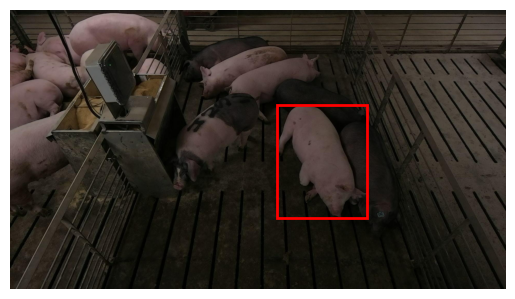

In [31]:
def show_image_with_bbox(image_path, bbox):
    image = Image.open(image_path)
    plt.imshow(image)
    x, y, width, height = bbox     
    plt.gca().add_patch(plt.Rectangle((x, y), width, height,
                                    edgecolor='red', facecolor='none', linewidth=2))
    plt.axis('off')
    plt.show()

def parse_bbox(bbox_str):
    if isinstance(bbox_str, str):
        return [float(x) for x in bbox_str.replace('[', '').replace(']', '').split(',')]
    return bbox_str

row = train1_df.iloc[0]
bbox_data = parse_bbox(row['bbox']) 
img_path = os.path.join(dir_train1, row['image_id'])
show_image_with_bbox(img_path, bbox_data)

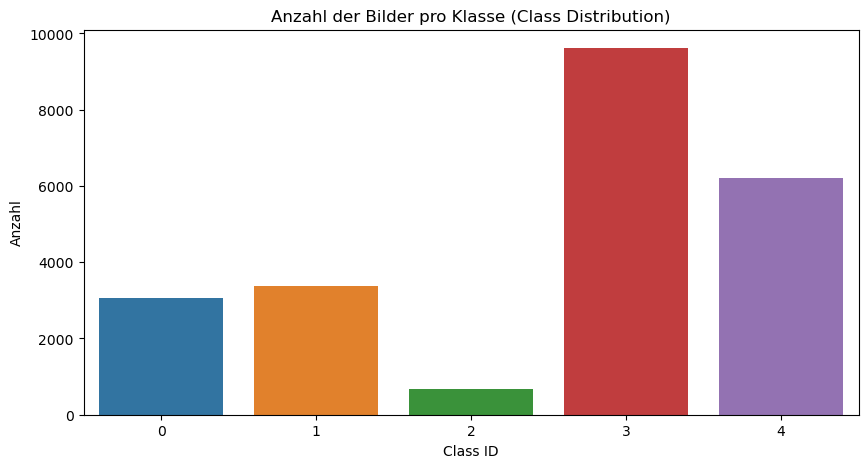

In [32]:
class_counts = train1_df['class_id'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Anzahl der Bilder pro Klasse (Class Distribution)')
plt.xlabel('Class ID')
plt.ylabel('Anzahl')
plt.show()

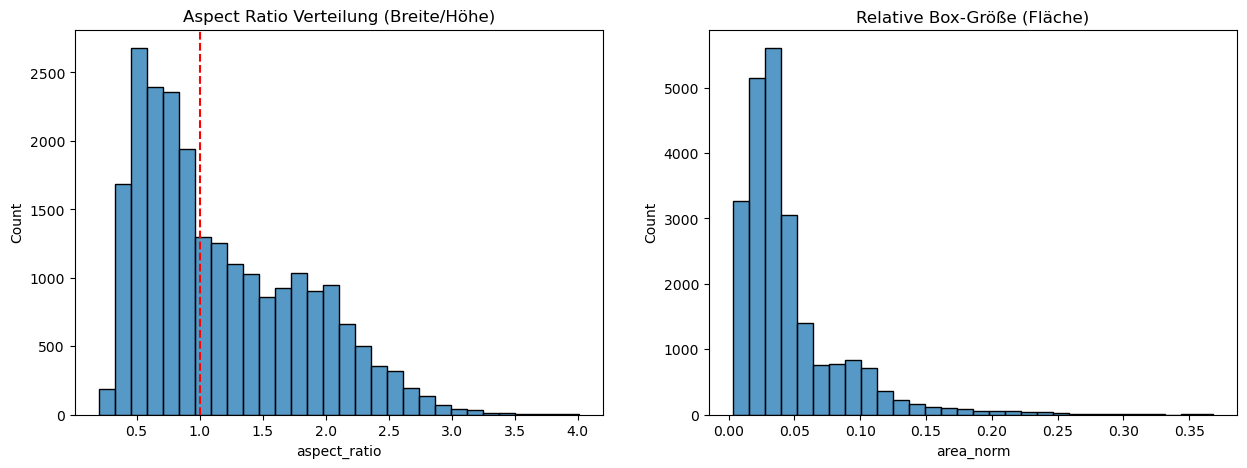

In [37]:
def parse_bbox_safe(x):
    if isinstance(x, str):
        # Klammern weg, splitten, zu Floats machen
        return [float(i) for i in x.replace('[', '').replace(']', '').split(',')]
    return x # Falls es schon eine Liste ist, einfach zurückgeben

# 2. KONVERTIERUNG: Wir wenden das auf die ganze Spalte an
# Das überschreibt die Strings mit echten Listen [x, y, w, h]
train1_df['bbox'] = train1_df['bbox'].apply(parse_bbox_safe)

# 3. DATAFRAME ERSTELLEN
# Jetzt funktioniert tolist(), weil es eine Liste von Listen erzeugt
bbox_data = train1_df['bbox'].tolist()
bbox_stats = pd.DataFrame(bbox_data, columns=['x', 'y', 'w', 'h'])

# --- JETZT LÄUFT IHRE EDA ---

# Aspekt-Ratio (Breite / Höhe)
bbox_stats['aspect_ratio'] = bbox_stats['w'] / bbox_stats['h']
# Fläche relativ zum Bild (normiert auf 1920x1080)
bbox_stats['area_norm'] = (bbox_stats['w'] * bbox_stats['h']) / (1920 * 1080)

# Visualisierung
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Wie "langgezogen" sind die Boxen?
sns.histplot(bbox_stats['aspect_ratio'], bins=30, ax=ax[0])
ax[0].set_title('Aspect Ratio Verteilung (Breite/Höhe)')
ax[0].axvline(1, color='red', linestyle='--') # Referenzlinie Quadrat

# Plot 2: Wie groß sind die Schweine im Bild?
sns.histplot(bbox_stats['area_norm'], bins=30, ax=ax[1])
ax[1].set_title('Relative Box-Größe (Fläche)')

plt.show()

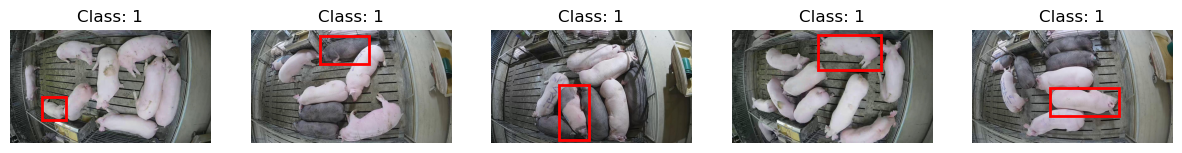

In [39]:
def show_grid_per_class(class_id, num_images=5):
    # Filtern nach Klasse
    subset = train1_df[train1_df['class_id'] == class_id].sample(n=num_images, replace=True)
    
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = os.path.join(dir_train1, row['image_id'])
        bbox = parse_bbox(row['bbox']) # Unsere Funktion von vorhin
        
        plt.subplot(1, num_images, i+1)
        image = Image.open(img_path)
        plt.imshow(image)
        
        x, y, w, h = bbox
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2))
        plt.axis('off')
        plt.title(f"Class: {class_id}")
    plt.show()

# Beispiel: Zeige 5 Bilder von Klasse 0
show_grid_per_class(1)